# Dokumentacja projektowa
## Temat pracy: Opracowanie hybrydowego systemu komunikacji optyczno-radiowej (VLC/RF) dla zapewnienia łączności obiektów IoT.
### Autor: Ivan Ovsiienko
#### Wersja: 18.05.26

### Rozdział I - Przegląd istniejących rozwiązań związanych z tematem pracy. 

---

#### 1. Wprowadzenie: Problem sieci IoT
Wraz z rozwojem Internetu Rzeczy (IoT), w domach i biurach pojawia się coraz więcej urządzeń (czujniki, inteligentne gniazdka). Większość z nich korzysta z pasma radiowego 2.4 GHz (Wi-Fi, Bluetooth, ZigBee). Powoduje to duży problem: widmo radiowe staje się przeciążone (saturacja). Zbyt duża liczba urządzeń powoduje zakłócenia, gubienie pakietów danych i opóźnienia. Dlatego konieczne jest szukanie innych metod komunikacji, które odciążą sieć Wi-Fi.
#### 2. Technologie: VLC i RF
Rozwiązaniem tego problemu jest wykorzystanie światła widzialnego (VLC - Visible Light Communication). Światło ma ogromną przepustowość i nie zakłóca się z falami radiowymi. Niestety, systemy oparte tylko na VLC mają wady: wymagają bezpośredniej widoczności (LOS - Line of Sight) i zużywają dużo energii podczas wysyłania danych, co jest problemem dla czujników na baterie.
Dlatego najlepszym kompromisem są systemy hybrydowe (VLC/RF). Łączą one zalety światła (szybkość w łączu w dół) i radia (przenikanie przez ściany w łączu w górę).
#### 3. Przegląd istniejących rozwiązań (State of the Art)
Koncepcja hybrydowych sieci OWC/RF (optyczno-radiowych) jest obecnie intensywnie badana przez środowiska naukowe. Analiza istniejących wdrożeń pokazuje ogromny potencjał tej technologii, ale też wskazuje na obszary wymagające optymalizacji:
- **Platforma IRON (Integrated RF - Optical Wireless)**: Jest to badawczy system IoT, w którym połączono mikrosieci świetlne (VLC) z radiem dalekiego zasięgu (LoRa). Światło tworzy bezpieczne, odizolowane "wyspy" komunikacyjne, a protokół radiowy służy do wysyłania komend zwrotnych i zgłaszania utraty sygnału optycznego. Choć system ten działa świetnie, jest zbyt skomplikowany i drogi dla standardowych zastosowań domowych.
- **Przemysłowe systemy m-Health (np. w górnictwie)**: W kopalniach, gdzie sygnał GPS i Wi-Fi zanika lub ulega silnym zakłóceniom (wielodrogowość fali radiowej), zastosowano systemy hybrydowe do śledzenia górników. Lampy (VLC) bezbłędnie i precyzyjnie lokalizują pracownika (Downlink), a czujniki w kasku wysyłają dane o jego zdrowiu za pomocą radia (Uplink). To rozwiązanie w praktyce udowodniło niezawodność podziału na kanał optyczny i radiowy.
- **Standardy nadchodzącej generacji (Li-Fi / IEEE 802.11bb)**: Organizacje standaryzujące pracują nad integracją technologii świetlnej ze standardem Wi-Fi (tzw. Li-Fi), celując w przepustowości rzędu gigabitów na sekundę. Wymaga to jednak potężnej mocy obliczeniowej i drogich komponentów.

**Wniosek z przeglądu**: Istniejące zaawansowane projekty skupiają się na przemyśle, medycynie i ekstremalnych prędkościach. Brakuje natomiast prostych, zoptymalizowanych kosztowo rozwiązań, które wykorzystywałyby te same, sprawdzone zasady (światło w dół, radio w górę) do obsługi dziesiątek małych urządzeń w zwykłym ekosystemie Smart Home.

#### 4. Koncepcja autorskiego projektu: Topologia Master-Slave
Aby wypełnić tę lukę, w niniejszej pracy zaprojektowano asymetryczną topologię Master-Slave, dostosowaną do tanich mikrokontrolerów. Istnieje wiele skomplikowanych modeli sieci, ale do inteligentnego domu (Smart Home) najlepiej nadaje się asymetryczna topologia Master-Slave.
- Master (Lampa sufitowa): Ma stałe zasilanie i dużą moc obliczeniową. Działa jako brama (Gateway). Wysyła dane do urządzeń za pomocą światła (Downlink/Broadcast). Aby ludzkie oko nie widziało migotania, stosuje się odpowiednie kodowanie.
- Slave (Czujniki i Gniazdka): Urządzenia końcowe z ograniczoną energią. Odbierają dane przez fotodiodę, ale odpowiedzi (Uplink) wysyłają za pomocą prostego modułu radiowego.
#### 5. Dlaczego takie rozwiązanie jest najlepsze? (Krytyczna analiza)
Wybór takiej architektury dla mojego prototypu opiera się na 5 głównych argumentach:
- **Odciążenie Wi-Fi**: Szerokopasmowe dane idą przez światło. Radio służy tylko do wysyłania krótkich potwierdzeń lub małych paczek danych (np. temperatury) w normalnym trybie pracy (no loss LOS) .
- **Prosta lokalizacja (Indoor Positioning)**: Światło nie przenika przez ściany. Jeśli czujnik widzi sygnał z konkretnej lampy, system na 100% wie, w którym pokoju się on znajduje. Fale radiowe tego nie potrafią.
- **Wysokie bezpieczeństwo**: Sygnału świetlnego nie da się podsłuchać z zewnątrz budynku (np. z ulicy), bo zatrzymują go rolety i ściany.
- **Oszczędzanie baterii w czujnikach**: Moduł radiowy w czujniku może być domyślnie wyłączony (uśpiony). Czujnik może być "wybudzany" specjalnym impulsem świetlnym z lampy, co pozwala baterii działać latami.
- **Działanie w ciemności**: Kiedy światło w pokoju jest wyłączone, system automatycznie przechodzi w tryb awaryjny (RF-First) i korzysta tylko z radia. W przyszłości można też dodać diody podczerwone (IR).
#### 6. Podsumowanie i cel pracy
Przegląd literatury pokazuje, że teoretyczne koncepcje systemów hybrydowych VLC/RF są już dobrze zbadane (np. w systemach ratunkowych w kopalniach). Brakuje jednak prostych i tanich implementacji sprzętowych dla zwykłych użytkowników.
Celem tej pracy nie jest wymyślanie nowej teorii, ale zbudowanie fizycznego prototypu (Proof of Concept). Projekt ma udowodnić, że wykorzystując dostępne, tanie mikrokontrolery można zbudować spersonalizowany, sprawnie działający hybrydowy system komunikacji, który rozwiązuje rzeczywiste problemy IoT.
#### 7. Literatura
- https://www.mdpi.com/2304-6732/13/2/163 Nguyen, D.T.; Nguyen, T.; Thieu, M.D.; Nguyen, H. A Deep Learning-Enhanced MIMO C-OOK Scheme for Optical Camera Communication in Internet of Things Networks. Photonics 2026, 13, 163. https://doi.org/10.3390/photonics13020163
- https://www.techrxiv.org/doi/full/10.36227/techrxiv.12659789.v2 Optical Wireless Communication for the Internet of Things: Advances, Challenges, and Opportunities; Authors: Abdelbaset Hamza and Tyler Tripp https://doi.org/10.36227/techrxiv.12659789.v2
- https://remarkable.ulusofona.pt/images/files/Achievements/IRON%20an%20Integrated%20RF-OWC%20System.pdf IRON: an Integrated RF-OWC System for Interoperability in IoT Systems. Authors: Anna Maria Vegni, Pietro Manzoni, and Milica Petkovic
Dept. of Industrial, Electronic and Mechanical Engineering, Roma Tre University, Italy.
Department of Computer Engineering, Universitat Politecnica de Val`encia, Spain. Faculty of Technical Sciences, University of Novi Sad, Serbia.
- https://www.mdpi.com/1424-8220/23/17/7545 Article: A Review of Hybrid VLC/RF Networks: Features, Applications, and Future Directions
Authors: by Lisandra Bravo Alvarez,Samuel Montejo-Sánchez,Lien Rodríguez-López,Cesar Azurdia-Meza andGabriel Saavedra
- https://pmc.ncbi.nlm.nih.gov/articles/PMC10780459/ Iturralde D, Guaña-Moya J, Játiva PP, et al. A New Internet of Things Hybrid VLC/RF System for m-Health in an Underground Mining Industry. Sensors (Basel). 2023;24(1):31. Published 2023 Dec 20. doi:10.3390/s24010031


### Rozdział II - Analiza wymagań i dobór komponentów. 

1. **Architektura Sieci i Topologia Systemu**
    1. Model Hybrydowy (Master-Slave): Podział ról w systemie. ESP32 jako brama brzegowa (Edge Gateway) i Arduino jako ultra-energooszczędny węzeł końcowy (Edge Node).
    2. Skalowalność i problem "Wielu Lamp": Jak system zachowa się w dużym pomieszczeniu. Rozwiązania zapobiegające nakładaniu się sygnałów świetlnych i radiowych (koncepcje TDMA dla radia oraz FDMA/WDM dla potencjalnej rozbudowy świetlnej).
2. **Warstwa Sprzętowa (Hardware)**
    1. Jednostki Obliczeniowe: Uzasadnienie wyboru platform – dlaczego ESP32 (moc, Wi-Fi, timery) na bramce i dlaczego Arduino/ATmega328P (przewidywalność, ultra-niski pobór prądu w trybie Sleep) na czujniku.
    2. Nadajnik Optyczny (Lampa): Budowa modułu nadawczego na bazie matrycy 10 diod RGB. Projektowanie układu zasilania (tranzystory kluczujące) i otwarta architektura pozwalająca na przyszłą migrację do taśm LED lub lamp 12V.
    3. Moduł Radiowy (Uplink/Sync): Uzasadnienie wyboru modułu NRF24L01 (Enhanced ShockBurst, ACK Payload).
3. **Projektowanie architektury i implementacja systemu**
    1. Schemat w LTSpice i Omówienie Nadajnika VLC 
    2. Schemat Odbiornika w LTSpice: Omówienie zaprojektowanego układu wzmacniacza transimpedancyjnego (TIA).
    3. Sprzętowe Wybudzanie (Wake-up Interrupt): Wykorzystanie komparatora z histerezą do zamiany sygnału analogowego na czyste przerwanie cyfrowe (INT0). Eliminacja fałszywych wybudzeń.
4. **Warstwa Fizyczna i Kodowanie Danych**
    1. Modulacja Światła: Jak nadawać dane, by oko nie widziało migotania (częstotliwości nośne, stała średnia jasność, np. 50% PWM).
    2. Algorytmy Kodowania: Wybór schematu kodowania przesyłanych bitów (np. Manchester lub OOK) dostosowanego do toru analogowego.
5. **Hybrydowy Protokół Komunikacyjny (TDMA) i Czas Rzeczywisty**
    1. Dystrybucja Czasu Absolutnego: Wykorzystanie modułu Wi-Fi w ESP32 do pobierania czasu ze światowych serwerów NTP. ESP32 jako lokalny "wzorzec czasu".
    2. Architektura Slotów Czasowych (TDMA): Przejście z asynchronicznego nasłuchu na precyzyjne okna czasowe zarządzane przez zegar RTC (np. DS3231) w węźle Arduino.
    3. Uproszczony Protokół PTP (Precision Time Protocol): * Szykanie opóźnień: Testowanie RTT (Round Trip Time).
        - Algorytmy korekcji dryfu zegara (Clock Drift Compensation) za pomocą pakietów ACK Payload.
    4. Klasyfikacja Węzłów: Różnice w algorytmach synchronizacji dla czujników stacjonarnych (rzadkie testy RTT) i mobilnych/przenośnych (częsta korekcja).
6. **Odporność na Błędy i Mechanizmy Niezawodności (Fail-Safe)**
    1. Detekcja Utraty Sygnału (Zasłonięcie Odbiornika): Scenariusz utraty widoczności optycznej (LOS - Line of Sight).
    2. Autonomiczna Reanimacja Węzła: Algorytm wykorzystujący zapasowe "okna radiowe" oraz procedurę twardego resetu synchronizacji za pomocą awaryjnego błysku świetlnego (Light & RF Sync Check).


#### 1.1 Model Hybrydowy
Wybór odpowiedniej topologii sieciowej jest fundamentalnym krokiem w projektowaniu hybrydowego systemu komunikacji (VLC/RF). Topologia determinuje nie tylko sposób przepływu danych, ale przede wszystkim narzuca ograniczenia sprzętowe, definiuje budżet energetyczny urządzeń oraz wpływa na całkowitą niezawodność infrastruktury. W kontekście sieci IoT najczęściej rozpatruje się cztery modele architektoniczne: Gwiazdę (Master-Slave), Siatkę (Mesh), strukturę Punkt-Punkt (Peer-to-Peer) oraz topologię Drzewa (Cluster-Tree).

| Kryterium analityczne | Gwiazda (Master-Slave) | Siatka (Mesh) | Peer-to-Peer (P2P) | Drzewo (Cluster-Tree) |
| :--- | :--- | :--- | :--- | :--- |
| **Zasada działania** | Centralna brama (Master) zarządza i komunikuje się ze wszystkimi węzłami podrzędnymi (Slave). | Każdy węzeł komunikuje się z sąsiadami, pełniąc rolę przekaźnika (routera) dla innych. | Bezpośrednia, niezależna wymiana danych między dwoma dowolnymi urządzeniami. | Układ hierarchiczny: Główna brama zarządza routerami, które obsługują własne grupy węzłów. |
| **Złożoność implementacji (Hardware/Software)** | **(+)** Niska. Węzły końcowe nie wymagają skomplikowanych protokołów routingu ani dużej pamięci. | **(–)** Bardzo wysoka. Wymaga zaawansowanych algorytmów routingu i dużej mocy obliczeniowej każdego węzła. | **(~)** Niska do średniej. Brak centralnego zarządzania ułatwia budowę pojedynczego łącza. | **(–)** Wysoka. Wymaga sprzętu o różnej wydajności w zależności od roli (Brama vs Router vs Węzeł). |
| **Zużycie energii (Węzły końcowe)** | **(+)** Bardzo niskie. Węzeł może przebywać w trybie uśpienia (Deep Sleep) i budzić się tylko na czas transmisji. | **(–)** Wysokie. Urządzenia muszą nieustannie nasłuchiwać i przekazywać pakiety innych urządzeń w sieci. | **(~)** Średnie do wysokich. Zależne od czasu synchronizacji dwóch urządzeń. | **(+)** Niskie dla węzłów końcowych ("liści"), ale wysokie dla węzłów pełniących funkcje węzłów pośrednich.* |
| **Niezawodność (Fault Tolerance)** | **(–)** Niska. System posiada pojedynczy punkt awarii (Single Point of Failure). Awaria Mastera kładzie mikro-komórkę. | **(+)** Bardzo wysoka. Sieć jest samonaprawiająca się. Awaria węzła powoduje zmianę ścieżki routingu. | **(~)** Średnia. Awaria jednego urządzenia zrywa tylko jedno konkretne połączenie. | **(~)** Średnia. Awaria routera pośredniego odcina całą przypisaną do niego gałąź (podsieć).  |
| **Opóźnienia transmisyjne (Latency)** | **(+)** Niskie i przewidywalne (zawsze 1 skok transmisyjny / hop). | **(~)** Zmienne i często wysokie (zależne od liczby skoków między węzłami i obciążenia). | **(+)** Bardzo niskie (komunikacja bezpośrednia). | **(+)** Zmienne (wzrastają wraz z głębokością drzewa logicznego).**
| **Dopasowanie do specyfiki hybrydy VLC/RF** | **(+)** Bardzo dobre. Światło (Master) nadaje szerokim kątem (Downlink), radio (Slave) wraca bezkolizyjnie (Uplink). | **(–)** Słabe. Wymagałoby umieszczania nadajników optycznych w czujnikach i celowania w inne czujniki (LOS). | **(–)** Słabe. Skuteczne tylko przy stałym, precyzyjnym wycelowaniu fotodetektorów na emitery. | **(+)** Dobre (skalowanie). Lampa Master może być podpięta do głównej bramy w budynku (np. przez Ethernet/Wi-Fi). |

<span style="font-size:xx-small">* - Przyjmujemy że zasilanie bateryjne potrzebne tylko dla węzłów końcowych. Węzły pośrednie to są lampy zasilane z sieci.</span>  
<span style="font-size:xx-small">** \- Zakładamy ze w topologii drzewa nie bedzie hierarchii głębszej niż 4: Węzeł końcowy ← Węzeł pośredni ← Główny kontroler ← Użytkownik. </span>
  

Biorąc pod uwagę powyższe, obiektywne zestawienie, topologia Siatki (Mesh), choć oferuje najwyższą niezawodność, całkowicie wyklucza zastosowanie ultra-energooszczędnych węzłów bateryjnych, zmuszając je do ciągłego nasłuchu. Podobnym problemem obarczona jest topologia P2P. Ponadto fizyka światła widzialnego (kierunkowość i wymóg linii widzenia - LOS) sprawia, że komunikacja optyczna pomiędzy dwoma czujnikami (jak wymagałby tego Mesh lub P2P) jest praktycznie niemożliwa.

Z kolei topologia Drzewa (Cluster-Tree), będąca naturalnym konkurentem dla topologii Gwiazdy, stanowi zbyt skomplikowany układ, który wykracza poza ramy budowy pojedynczego łącza hybrydowego i obejmuje zarządzanie całym ekosystemem Smart Home. De facto, pojedyncza Gwiazda stanowi wyizolowaną komórkę (np. jedno pomieszczenie) w budynku. Skalowanie systemu, polegające na zwielokrotnieniu takich komórek i połączeniu ich z nadrzędnym kontrolerem centralnym, w naturalny sposób doprowadziłoby do utworzenia topologii Drzewa. Taka ścieżka stanowi optymalny kierunek przyszłego rozwoju systemu. Jednakże realizacja tak rozbudowanej architektury wykracza poza zakres niniejszej pracy inżynierskiej, której głównym celem jest stworzenie i zbadanie podstawowej komórki komunikacyjnej na poziomie Proof-Of-Concept.

Z tego względu jedynym racjonalnym i zoptymalizowanym wyborem dla systemu wewnątrzbudynkowego, łączącego zalety szerokopasmowego oświetlenia z wąskopasmowym radiem, jest architektura Master-Slave (Gwiazda). Przypisanie roli węzła Master do infrastruktury oświetleniowej (zasilanej z sieci 230V) eliminuje problem zapotrzebowania energetycznego nadajników LED. Z kolei narzucenie czujnikom roli podrzędnej (Slave) zwalnia je z zadań routingu, co pozwala na drastyczne obniżenie poboru prądu i bezproblemową realizację asymetrycznego łącza uplink za pomocą energooszczędnych modułów radiowych. Mimo wady w postaci pojedynczego punktu awarii (lampa), w typowym ekosystemie pomieszczenia (tzw. mikro-komórce optycznej) jest to koszt w pełni akceptowalny z inżynierskiego punktu widzenia.

#### 1.2 Skalowalność i problem "Wielu Lamp" Model Hybrydowy
Wdrażanie technologii VLC w wielkopowierzchniowych pomieszczeniach mieszkalnych, biurowych lub halach przemysłowych wymaga zastosowania wielu źródeł światła w celu zapewnienia równomiernego oświetlenia. W klasycznej architekturze komunikacyjnej prowadzi to do zjawiska nakładania się stożków świetlnych generowanych przez sąsiadujące oprawy. Jeżeli każda lampa transmituje niezależne dane w tym samym czasie i na tej samej długości fali, odbiornik znajdujący się w strefie częściowego pokrycia obu lamp ulega tzw. interferencji współkanałowej (Co-Channel Interference - CCI). Odczyt danych staje się wówczas niemożliwy z powodu nałożenia się na siebie niesynchronicznych zboczy sygnałów świetlnych.

Rozwiązanie tego problemu i zapewnienie płynnej komunikacji w środowisku "Wielu Lamp" (Multi-cell VLC) wymaga wdrożenia odpowiednich technik wielodostępu lub modyfikacji architektury logicznej warstwy fizycznej. W Tabeli 2 zestawiono i obiektywnie przeanalizowano dostępne w literaturze inżynieryjnej metody mitigacji tego zjawiska.

| Metoda mitigacji | Zasada działania | Wymagania sprzętowe / Złożoność | Główne zalety | Główne wady |
| :--- | :--- | :--- | :--- | :--- |
| **Pojedyncza Brama (Single Edge Gateway)** | W danym pomieszczeniu tylko jedna centralna oprawa (Master) posiada moduł nadawczy VLC. Pozostałe lampy stanowią wyłącznie standardowe oświetlenie. | Bardzo niskie. Brak skomplikowanych układów w sieci zasilającej. | Brak interferencji optycznej; najniższy koszt implementacji. | Wysokie ryzyko utraty łączności (zacienienie - blokada LOS z jednej lampy przerywa transmisję w dół). |
| **Transmisja Równoległa (Simulcast)** | Wszystkie oprawy w pomieszczeniu są przewodowo zsynchronizowane i nadają dokładnie ten sam sygnał optyczny w tym samym czasie. | Niskie do średnich. Wymaga magistrali synchronizującej wszystkie lampy (np. RS-485 / DALI). | Wyeliminowanie zakłóceń w strefach nakładania; rozwiązuje problem zacienienia pojedynczej lampy (makro-dywersyfikacja). | Marnotrawstwo potencjalnej przepustowości (pomieszczenie działa jak jedna komórka o pojemności jednej lampy). |
| **Separacja Przestrzenna (Power/Spatial Planning)** | Lampy nadają niezależne dane, ale ich optyka (soczewki) i moc są tak dobrane, że w strefach styku sygnał z jednej lampy jest o rzędy wielkości słabszy od drugiej (różnica mocy). | Średnie. Wymaga zaawansowanego projektowania fotometrycznego soczewek i pozycjonowania mebli. | Pozwala na pracę wielu niezależnych mikro-komórek bez dzielenia pasma i czasu. | Niezmiernie trudne do utrzymania w praktyce domowej z powodu odbić sygnału (NLOS) od podłóg i ścian. |
| **Podział Czasu (TDMA)** | Każda lampa w pomieszczeniu nadaje sygnał we własnej, ściśle przydzielonej i niesynchronizowanej z innymi oknie czasowym (Time Slot). | Średnie. Wymaga bardzo precyzyjnej synchronizacji zegarów na poziomie bramek (np. przez PTP). | Brak interferencji; każda lampa może nadawać inne dane kierowane do specyficznych sektorów pokoju. | Spadek całkowitej przepustowości proporcjonalny do liczby lamp (każda lampa "milczy" w oknach sąsiadów). |
| **Podział Częstotliwości (FDM / FDMA)** | Każda lampa moduluje dane na innej częstotliwości nośnej (podnośnej, tzw. Subcarrier Multiplexing). | Bardzo wysokie. Wymaga szybkich przetworników ADC w odbiorniku oraz sprzętowej analizy widma (np. FFT). | Możliwość jednoczesnej i ciągłej transmisji niezależnych danych z wielu opraw na raz. | Zbyt obciążające obliczeniowo dla energooszczędnych mikrokontrolerów klasy IoT. |
| **Podział Długości Fali (WDM / Color)** | Każda lampa używa innej barwy światła (np. jedna nadaje czerwoną, sąsiadująca zieloną) do transmisji danych. | Bardzo wysokie. Wymaga matryc RGB-LED w lampach i filtrów dichroicznych lub potrójnych fotodiod w węzłach. | Gigantyczna pojemność systemu; absolutny brak interferencji na poziomie fizycznym kanału. | Złożoność optyki i wysoki koszt fotodetektorów wyklucza to rozwiązanie z tanich systemów IoT. |
| **Podział Kodowy (Optical CDMA)** | Lampy nadają jednocześnie, ale ich bity są mnożone przez unikalne, ortogonalne kody optyczne (OOC). Odbiornik dekoduje sygnał korelacyjnie. | Wysokie. Odbiornik musi operować na częstotliwości (chip rate) znacznie przewyższającej szybkość użyteczną danych. | Odporność na zakłócenia wielodrogowe; płynne przełączanie urządzeń w ruchu. | Poziom skomplikowania cyfrowego przetwarzania sygnału (DSP) przekracza możliwości tanich modułów krawędziowych. |

Analiza dostępnych mechanizmów wykazuje radykalny podział w zależności od dostępnej mocy obliczeniowej oraz tolerowanego kosztu urządzeń. W zaawansowanych systemach gigabitowych powszechnie stosuje się WDM oraz FDM, jednak wymagają one użycia kosztownych elementów optoelektronicznych oraz procesorów DSP, co stoi w sprzeczności z ideą tanich, bateryjnych układów brzegowych, w których odbiornik fotometryczny ma być maksymalnie uproszczony (prosty wzmacniacz TIA połączony z przerwaniem mikrokontrolera).

Dla architektury zorientowanej na niskokosztowe elementy IoT (np. mikrokontrolery serii ATmega czy ESP), procesy wymagające analizy widmowej lub zaawansowanej filtracji sprzętowej należy odrzucić. W tym kontekście najbardziej racjonalnymi rozwiązaniami w ramach projektowania hybrydy stają się:

* Topologia Pojedynczej Bramy (Single Gateway) – ze względu na drastyczne obcięcie kosztów sprzętowych.

* Topologia Simulcast – ze względu na naturalne wzmacnianie sygnału głównego i brak wymogu skomplikowanego dekodowania na prostych procesorach węzłów końcowych, kosztem połączenia przewodowego samych lamp na etapie instalacji elektrycznej.

* Implementacja warstwy TDMA – możliwa do realizacji, jeśli połączy się warstwę świetlną z powrotnym kanałem RF w celu ścisłej dystrybucji okien czasowych (tzw. ramkowanie hybrydowe).

Rozwiązanie problemu zwielokrotnienia nadajników determinować będzie finalną konstrukcję elektroniki w warstwie Master oraz stopień skomplikowania oprogramowania warstwy MAC.

##### 1.2.1 Analiza opóźnień propagacyjnych (Delay Spread) i uzasadnienie dla prostych systemów
Rozpatrując zjawisko naturalnych odbić wielodrogowych wewnątrz pomieszczenia lub topologię Simulcast, należy zweryfikować, czy różnica w czasie dotarcia sygnału świetlnego z różnych źródeł (lub po odbiciu od ścian) do odbiornika nie wpłynie negatywnie na spójność danych. Zjawisko to w telekomunikacji określa się jako rozpraszanie opóźnień (Delay Spread), co może prowadzić do interferencji międzysymbolowej (ISI – Inter-Symbol Interference), w której jeden bit danych "nakłada się" na kolejny.

Warto na wstępie zauważyć, że każda standardowa oprawa oświetleniowa LED (np. matryca w żarówce lub panelu sufitowym) składa się z kilkunastu lub kilkudziesięciu pojedynczych diod elektroluminescencyjnych połączonych równolegle lub szeregowo. Oznacza to, że z fizycznego punktu widzenia, nawet pojedyncza lampa funkcjonuje jako zintegrowany, zminiaturyzowany system Simulcast, w którym wiele emiterów nadaje dokładnie ten sam zmodulowany sygnał jednocześnie.

Aby udowodnić marginalny wpływ różnic propagacyjnych na systemy klasy IoT, przeprowadzono teoretyczne obliczenia dla skrajnie niekorzystnego przypadku (Worst-Case Scenario) w dużym pomieszczeniu.
##### 1.2.2 Model fizyczny:
Załóżmy przestronne pomieszczenie o wymiarach 10 m x 10 m x 3 m. Odbiornik znajduje się w jednym rogu pokoju na podłodze. Przyjmijmy maksymalną możliwą różnicę dróg optycznych – na przykład różnicę między sygnałem z lampy znajdującej się bezpośrednio nad odbiornikiem (droga ok. 3 m), a sygnałem z lampy w przeciwległym rogu sufitu, z uwzględnieniem dodatkowych odbić od ścian. Dla bezpieczeństwa obliczeń inżynierskich możemy założyć maksymalną różnicę dróg propagacyjnych na poziomie $\Delta d = 15$ m.Różnica czasu dotarcia obu sygnałów ($\Delta t$) zależy od prędkości światła w próżni ($c \approx 3 \cdot 10^8$ m/s) i wynosi:
$$\Delta t = \frac{\Delta d}{c} = \frac{15 \text{ m}}{3 \cdot 10^8 \text{ m/s}} = 50 \text{ ns}$$
Maksymalne opóźnienie sygnału wynosi zaledwie 50 nanosekund.Konfrontacja z wymaganiami przepustowości IoT:Węzły Internetu Rzeczy (czujniki, gniazdka) transmitują niewielkie pakiety danych. Zakładając relatywnie szybki dla IoT kanał optyczny o przepustowości $R = 2$ Mbps (2 Megabit na sekundę), czas trwania pojedynczego bitu (okres symbolu $T_{bit}$) wynosi:$$T_{bit} = \frac{1}{R} = \frac{1}{2*10^6 \text{ bps}} = 0.5 \text{ } \mu\text{s} = 500 \text{ ns}$$W analizowanym środowisku maksymalne opóźnienie wielodrogowe ($\Delta t = 50$ ns) stanowi dokładnie 10% czasu trwania pojedynczego bitu ($T_{bit} = 500$ ns). W praktyce inżynierskiej przyjmuje się, że jeśli opóźnienie propagacyjne jest mniejsze niż 10% czasu trwania symbolu, zjawisko ISI jest całkowicie pomijalne.Oznacza to, że dla systemów inteligentnego domu różnice fazowe wynikające z naturalnej budowy matryc LED, odbić od ścian, czy nawet zastosowania kilku zsynchronizowanych lamp, są zbyt małe, aby spowodować błąd odczytu w odbiorniku.
##### 1.2.3 Wybór rozwiązania dla celów projektowych:
Chociaż powyższa analiza bezsprzecznie udowadnia, że topologia Simulcast byłaby w pełni funkcjonalna i bezpieczna dla przepustowości rzędu 1 Mbps, w ramach niniejszej pracy inżynierskiej podjęto decyzję o wdrożeniu modelu Pojedynczej Bramy (Single Edge Gateway).Decyzja ta podyktowana jest zakresem projektu (Proof-of-Concept). Głównym celem pracy jest udowodnienie sprawności hybrydowego łącza asymetrycznego (VLC w dół, RF w górę) pomiędzy stacją bazową a ultraniskoenergetycznym węzłem końcowym w wyizolowanej mikro-komórce (np. w obrębie jednego biurka lub małego pokoju). Implementacja wielu lamp w systemie Simulcast lub TDMA wymagałaby budowy dodatkowej przewodowej magistrali synchronizacyjnej (np. RS-485) pomiędzy samymi oprawami na suficie, co drastycznie zwiększyłoby stopień skomplikowania sprzętowego, nie wnosząc jednocześnie nowej wiedzy w kontekście samego zjawiska hybrydyzacji komunikacji węzła IoT. Model jednej, inteligentnej lampy Master jest wystarczający do weryfikacji założeń badawczych.

#### 2.1 Warstwa Sprzętowa (Hardware) i dobór jednostek obliczeniowych
Asymetryczna topologia hybrydowego systemu komunikacji wymusza zróżnicowanie wymagań sprzętowych dla poszczególnych warstw sieci. Z tego względu proces doboru mikrokontrolerów został podzielony na dwie niezależne analizy: dla centralnej Bramy Brzegowej (Edge Gateway / Master) oraz dla Węzła Końcowego (Edge Node / Slave).
##### 2.1.1 Jednostka centralna: Brama Brzegowa (Master)
Brama zlokalizowana w oprawie oświetleniowej zasilanej napięciem sieciowym (230V) nie podlega restrykcjom energetycznym. Jej głównym zadaniem jest utrzymanie stabilnego połączenia z siecią nadrzędną (np. chmurą lub serwerem czasu NTP przez Wi-Fi/Ethernet), agregacja danych z sieci radiowej oraz precyzyjne generowanie strumieni danych dla kanału świetlnego (VLC) przy użyciu sprzętowych timerów i sygnałów PWM. W tabeli zestawiono popularne rodziny mikrokontrolerów rozpatrywane do tego zadania.
| Kryterium | ESP32 (Espressif) | STM32F4 (ARM Cortex-M4) | Raspberry Pi Pico (RP2040) | Arduino Mega (ATmega2560) |
| :--- | :--- | :--- | :--- | :--- |
| **Architektura i Taktowanie** | 32-bit Xtensa Dual-Core, 160-240 MHz | 32-bit ARM Cortex-M4, do 168 MHz | 32-bit Dual ARM Cortex-M0+, 133 MHz | 8-bit AVR, 16 MHz |
| **Łączność bezprzewodowa** | **(+)** Wbudowane Wi-Fi (802.11 b/g/n) oraz Bluetooth/BLE. | **(-)** Brak wbudowanej. Wymaga zewnętrznych modułów (np. ESP8266 po UART). | **(-)** Brak w standardzie (wymaga wersji Pico W z układem CYW43439). | **(-)** Brak wbudowanej łączności. |
| **Zasoby sprzętowe (Timery/PWM)** | **(+)** Wysoce zaawansowane. Moduł LEDC dedykowany do precyzyjnego generowania PWM o wysokich częstotliwościach. | **(+)** Profesjonalne timery sprzętowe o najwyższej rozdzielczości, wsparcie dla DMA. | **(+)** Bardzo dobre. Unikalny system PIO (Programmable I/O) do sprzętowej obsługi protokołów. | **(-)** Podstawowe timery 8/16-bit. Niska rozdzielczość przy wysokich częstotliwościach PWM. |
| **Trudność programowania** | **(~)** Średnia. Szerokie wsparcie społeczności, integracja z FreeRTOS oraz środowiskiem Arduino IDE. | **(-)** Wysoka. Wymaga znajomości rejestrów, narzędzi STM32CubeIDE oraz konfiguracji warstwy HAL. | **(~)** Średnia. Dobrze udokumentowany SDK w C/C++ oraz natywne wsparcie dla MicroPython. | **(+)** Bardzo niska. Idealny do prostych zadań edukacyjnych, brak wsparcia dla wielowątkowości. |
| **Szacunkowy koszt układu** | **(+)** Bardzo niski (ok. 15-25 PLN). | **(~)** Średni do wysokiego (zależny od płytki ewaluacyjnej, zazwyczaj > 50 PLN). | **(+)** Bardzo niski (ok. 20-30 PLN). | **(~)** Średni (ok. 50-80 PLN za oryginalne klony/płytki). |

<span style="color: #343434;font-size:large">**Wybór dla układu Master:**</span> 

Analiza wykazuje, że do realizacji węzła nadrzędnego (Master) zdecydowanym faworytem jest układ ESP32. Deklasuje on starsze konstrukcje 8-bitowe (ATmega2560) pod względem wydajności, oferując jednocześnie sprzętowy moduł Wi-Fi zintegrowany wewnątrz jednego układu SoC, co eliminuje konieczność stosowania zewnętrznych modułów komunikacyjnych (jak w przypadku bazowego RP2040 czy STM32). Obecność dwóch niezależnych rdzeni (Dual-Core) pozwala na optymalny podział zadań: jeden rdzeń może obsługiwać protokoły sieciowe i pobieranie czasu z serwerów NTP, podczas gdy drugi, działający w czasie rzeczywistym z systemem FreeRTOS, może bez zakłóceń generować wysokoczęstotliwościowy sygnał PWM dla matrycy LED w kanale VLC.

##### 2.1.2 Jednostka końcowa: Czujnik/Aktuator (Slave)
Dla asymetrycznego węzła podrzędnego, priorytety ulegają całkowitemu odwróceniu. Mikrokontroler zasilany z baterii musi charakteryzować się mikroskopijnym poborem prądu w trybie głębokiego uśpienia (Deep Sleep) oraz przewidywalnym czasem wybudzania. Co więcej, aby precyzyjnie reagować na sygnał optyczny z obwodu analogowego (przerwania sprzętowe), układ nie powinien być obciążony działaniem systemów operacyjnych czasu rzeczywistego (RTOS) ani skomplikowanymi stosami sieciowymi działającymi w tle.

| Kryterium | ATmega328P (rodzina Arduino) | ESP8266 | STM32L0 (ARM Cortex-M0+) | ATtiny85 |
| :--- | :--- | :--- | :--- | :--- |
| **Architektura i Taktowanie** | 8-bit AVR, 8-16 MHz. | 32-bit Tensilica, 80/160 MHz. | 32-bit ARM Cortex-M0+, 32 MHz. | 8-bit AVR, 1-8 MHz (wewn. oscylator). |
| **Pobór prądu (Deep Sleep / Power-Down)** | **(+)** ~0.1 µA - 1 µA (wybitnie oszczędny przy wyłączonych peryferiach). | **(-)** ~20 µA (stosunkowo wysoki jak na zasilanie bateryjne). | **(+)** ~0.3 µA (stworzony specjalnie dla urządzeń Ultra-Low Power). | **(+)** ~0.1 µA (znakomity dla prostych układów bateryjnych). |
| **Przewidywalność obsługi przerwań (ISR)** | **(+)** Bardzo wysoka (Bare-metal). Pełna kontrola nad wektorami przerwań zewnętrznych (INT0/INT1). | **(-)** Niska. Wymaga obsługi stosu Wi-Fi, co może wprowadzać opóźnienia. | **(+)** Bardzo wysoka. Zaawansowany kontroler przerwań (NVIC) z priorytetyzacją. | **(~)** Bardzo wysoka, jednak mocno ograniczona liczba pinów wejścia/wyjścia. |
| **Czas wybudzania ze snu (Wake-up time)** | **(+)** Poniżej 10 µs (błyskawiczna reakcja na impuls świetlny). | **(-)** Nawet do kilkuset milisekund (pełny restart rdzenia). | **(+)** Ok. 3.5 µs (wybudzanie bezpośrednio z pamięci RAM). | **(+)** Poniżej 10 µs. |
| **Trudność implementacji sprzętowej** | **(+)** Bardzo niska. Środowisko Arduino i bogate biblioteki dla radia SPI (NRF24L01). | **(~)** Średnia/Niska (środowisko Arduino). | **(-)** Wysoka. Wymaga dedykowanej płytki PCB lub użycia platform Nucleo. | **(~)** Niska, ale mało pamięci Flash (8 kB) i brak pełnego sprzętowego SPI. |
| **Szacunkowy koszt układu ewaluacyjnego** | **(+)** Bardzo niski (ok. 20-40 PLN za płytki typu Uno, Nano lub Pro Mini). | **(+)** Bardzo niski (ok. 15-20 PLN). | **(~)** Średni (ok. 50-80 PLN za oryginalne płytki ewaluacyjne Nucleo). | **(+)** Ekstremalnie niski (ok. 5-10 PLN za sam układ scalony). |

<span style="color: #343434;font-size:large">Wybór dla układu Slave:</span>

Choć platformy z rodziny STM32L0 stanowią technologiczny szczyt w dziedzinie układów ultra-niskoenergetycznych (Ultra-Low Power), do realizacji hybrydowego węzła podrzędnego zdecydowano się na klasyczny mikrokontroler 8-bitowy ATmega328P.

Wybór ten podyktowany jest niespotykanym stosunkiem energooszczędności do łatwości implementacji. ATmega328P pracujący w trybie Power-Down pobiera prąd rzędu ułamków mikroampera. Co ważniejsze, układ ten operuje natywnie w architekturze "bare-metal" (bez nadrzędnego systemu operacyjnego), co gwarantuje deterministyczny, sprzętowy czas reakcji na zewnętrzne przerwania analogowe (pin INT0) wyzwalane przez fotodetektor sygnału VLC. Wykluczono układ ESP8266 ze względu na niedopuszczalnie długi czas wybudzania ze stanu głębokiego snu, a układ ATtiny85 odrzucono z uwagi na niewystarczającą liczbę wyprowadzeń I/O do jednoczesnej obsługi toru świetlnego oraz magistrali SPI sprzętowego modułu radiowego (NRF24L01).

Warto zaznaczyć, że w docelowym, komercyjnym urządzeniu IoT węzeł ten powinien zostać zrealizowany na minimalistycznej płytce (np. Arduino Pro Mini 3.3V) w celu drastycznej redukcji fizycznych gabarytów oraz usunięcia zbędnych układów peryferyjnych (np. konwerterów USB-UART) pobierających prąd spoczynkowy. Jednakże, na potrzeby weryfikacji sprzętowej w ramach niniejszej pracy (Proof-of-Concept), testy zostaną przeprowadzone na standardowej platformie ewaluacyjnej Arduino Uno. Decyzja ta wynika z faktu posiadania tej platformy na obecnym wyposażeniu zaplecza laboratoryjnego, co pozwala na optymalizację kosztów budowy prototypu, nie wpływając jednocześnie w żaden sposób na poprawność testowania samej koncepcji komunikacyjnej – oba moduły bazują na identycznym rdzeniu obliczeniowym ATmega328P i zapewniają pełną kompatybilność rejestrów i algorytmów operacyjnych.

 

#### 2.2 Nadajnik Optyczny (Lampa Master) i wybór komponentów

Głównym elementem warstwy nadawczej systemu jest oprawa oświetleniowa, pełniąca rolę stacji bazowej. Zaprojektowanie tego modułu wymaga doboru odpowiednich źródeł światła, które potrafią pracować z wysoką częstotliwością przełączania (kluczowania).

<span style="color: #343434;font-size:large">**Porównanie technologii diod LED:**</span> 

Standardowe, białe diody LED wykorzystują warstwę luminoforu (tzw. fosforu) do uzyskania odpowiedniej barwy światła. Niestety, materiał ten charakteryzuje się zjawiskiem poświaty – emituje światło jeszcze przez krótki czas po odcięciu zasilania. Proces ten znacząco spowalnia narastanie i opadanie sygnału optycznego, co drastycznie ogranicza maksymalną przepustowość danych. W Tabeli 5 zestawiono właściwości popularnych typów diod pod kątem zastosowania w szybkiej komunikacji VLC/OWC.

| Kryterium | Białe diody LED (z fosforem) | Diody RGB (bez fosforu) | Diody Podczerwone (IR)* |
| :--- | :--- | :--- | :--- |
| **Prędkość modulacji (Przepustowość)** | **(-)** Niska. Poświata luminoforu ogranicza częstotliwość pracy zazwyczaj do kliku MHz. | **(+)** Bardzo wysoka. Brak fosforu pozwala na kluczowanie z częstotliwością przekraczającą 20 MHz. | **(+)** Bardzo wysoka. Struktura sprzętowa pozwala na prędkości zbliżone do diod RGB. |
| **Funkcja oświetlenia wewnątrzbudynkowego** | **(+)** Bardzo dobra. Zapewniają optymalne, naturalne białe światło. | **(+)** Dobra. Można uzyskać białe światło poprzez wymieszanie barw (R, G, B), choć o nieco gorszych parametrach oddawania barw. | **(-)** Brak. Promieniowanie podczerwone jest całkowicie niewidoczne dla człowieka.  |
| **Złożoność układu sterującego** | **(+)** Niska. Wymaga sterowania tylko jednym kanałem zasilającym. | **(~)** Średnia. Pełna kontrola koloru wymaga zastosowania trzech niezależnych kanałów PWM. | **(+)** Niska. Podobnie jak w przypadku białych diod LED. |
| **Koszty implementacji** | **(+)** Bardzo niskie. Są to najtańsze i najbardziej powszechne źródła światła na rynku. | **(~)** Średnie. Koszt jest wyższy z uwagi na integrację trzech oddzielnych struktur półprzewodnikowych w jednej obudowie. | **(+)** Bardzo niskie. Komponenty powszechnie stosowane m.in. w pilotach zdalnego sterowania. |

<span style="font-size:xx-small">* - Nie spełniają definicji systemu VLC. Klasyfikowane jako modyfikacja/rozszerzenie VLC, a nie rozwiązanie bazowe (rdzeń).</span>


<span style="color: #343434;font-size:large">**Decyzja o wyborze komponentów do prototypu**</span> 

Na podstawie powyższej analizy, w projektowanym urządzeniu zdecydowano się zastosować matrycę 10 sztuk diod RGB (jest zawsze możliwość rozbudowy) zasilanych napięciem 5V (w konfiguracji Common Anode – wspólna anoda). Wybór konfiguracji ze wspólną anodą nie jest przypadkowy i wynika z fizyki układów elektronicznych. Taki układ pozwala na sterowanie diodami od strony masy (tzw. Low-Side Switching) przy użyciu tranzystorów polowych typu N-MOSFET. Tranzystory N-kanałowe, w porównaniu do tranzystorów P-MOSFET (które byłyby niezbędne przy wspólnej katodzie), charakteryzują się mniejszą rezystancją oraz potrafią otwierać się i zamykać znacznie szybciej. W komunikacji VLC, gdzie tranzystor musi przełączać prąd miliony razy na sekundę, jest to cecha krytyczna. Ponadto, wykorzystanie samych struktur RGB pozwala fizycznie wyeliminować problem opóźnień wprowadzanych przez luminofor z białych diod. W celu uproszczenia obwodu na etapie weryfikacji prototypu (Proof-of-Concept), wyprowadzenia poszczególnych barw (R, G, B) połączono równolegle. Pozwala to na uzyskanie jasnego światła oświetleniowego przy jednoczesnym zachowaniu bardzo krótkiego czasu reakcji na impulsy sterujące.

<span style="color: #343434;font-size:large">**Układ zasilania(Tranzystor i Driver MOSFET):**</span>

Zasilanie matrycy LED bezpośrednio z wyprowadzeń mikrokontrolera ESP32 (pracującego w logice 3.3V) jest niemożliwe ze względu na bardzo niską wydajność prądową tych pinów. Wymagane jest zastosowanie tranzystora pełniącego funkcję szybkiego klucza elektronicznego.

Do tego celu wybrano tranzystor polowy MOSFET typu IRLZ44N. Posiada on bramkę typu "Logic-Level", co oznacza, że ułatwia załączanie przy niższych napięciach sterujących. Pojawia się tu jednak problem inżynierski: bramka tranzystora polowego zachowuje się jak kondensator. Mikrokontroler pracujący z częstotliwością kilku megaherców nie jest w stanie dostarczyć wystarczającego prądu, aby błyskawicznie przeładować pojemność tej bramki. W efekcie tranzystor otwierałby się zbyt wolno, co zniekształciłoby sygnał świetlny.

Aby rozwiązać ten problem, pomiędzy mikrokontroler ESP32 a tranzystor IRLZ44N wpięto dedykowany sterownik bramki – układ TC4427. Pełni on funkcję wzmacniacza sygnału: pobiera słaby impuls z procesora i dostarcza do bramki tranzystora prąd o wysokim natężeniu, wymuszając jego natychmiastowe przełączenie. Należy uczciwie zaznaczyć, że w profesjonalnych rozwiązaniach o wyższej przepustowości stosuje się bardziej zaawansowane komponenty (np. szybkie tranzystory z azotku galu – GaN). Niemniej jednak, duet TC4427 i IRLZ44N charakteryzuje się niską ceną, dużą dostępnością oraz parametrami w zupełności wystarczającymi do poprawnego działania prototypowego systemu dla Internetu Rzeczy.

<span style="color: #343434;font-size:large">**Otwarta architektura na przyszłość**</span>

Zaprojektowany obwód sterujący posiada otwartą architekturę (Open Architecture). Choć w obecnym modelu testowym użyto zasilania 5V, układ jest przystosowany do pracy z wyższymi napięciami. Umożliwia to przyszłą rozbudowę projektu i łatwą migrację do sterowania standardowymi taśmami LED 12V lub komercyjnymi oprawami świetlnymi, bez konieczności zmiany topologii modułu kluczującego. Schemat elektryczny obwodu zostanie omówiony w rozdziale poświęconym implementacji sprzętowej.

#### 2.3 Moduł Radiowy (Uplink/Sync)
W projektowanym systemie hybrydowym (VLC/RF), światło widzialne odpowiada za szybką komunikację w dół (Downlink). Aby jednak zamknąć pętlę komunikacyjną, węzeł końcowy musi mieć możliwość przesyłania danych powrotnych do stacji bazowej (Uplink) oraz odbierania sygnałów synchronizacyjnych, gdy światło jest wyłączone lub zasłonięte.

Ponieważ węzły końcowe w sieciach IoT są zazwyczaj zasilane bateryjnie, wybór modułu radiowego musi opierać się na kompromisie między zasięgiem, prędkością przesyłu danych a minimalnym zużyciem energii. W tabeli obiektywnie zestawiono najpopularniejsze na rynku moduły komunikacji bezprzewodowej, rozpatrywane pod kątem pracy w mikro-komórce wewnątrz pomieszczenia.

| Kryterium | NRF24L01+ | LoRa (np. SX1278) | HC-12 (CC1101) | Wi-Fi (np. ESP8266) |
| :--- | :--- | :--- | :--- | :--- |
| **Pasmo pracy** | 2.4 GHz (pasmo ISM) | 433 MHz / 868 MHz | 433 MHz | 2.4 GHz |
| **Zasięg wewnątrz budynku** | **(+)** Krótki / Średni (ok. 10 - 30 metrów). | **(-)** Bardzo duży (przenika przez wiele ścian i stropów). | **(-)** Duży (dobra przenikalność fal sub-GHz przez ściany). | **(~)** Średni (ok. 20 - 40 metrów, zależnie od routera). |
| **Prędkość transmisji danych** | **(+)** Bardzo wysoka (do 2 Mbps). | **(-)** Bardzo niska (często poniżej 10 kbps). | **(~)** Średnia (od 1 kbps do 115 kbps). | **(+)** Bardzo wysoka (powyżej 10 Mbps). |
| **Pobór prądu w uśpieniu (Power-Down)** | **(+)** Bardzo niski (ok. 0.9 µA). | **(+)** Niezwykle niski (ok. 0.2 µA). | **(~)** Niski (ok. 20 µA do 80 µA zależnie od trybu). | **(-)** Wysoki (ok. 20 µA, długa procedura wybudzania). |
| **Pobór prądu przy nadawaniu (TX)** | **(+)** Niski (ok. 11.3 mA przy mocy 0 dBm). | **(-)** Wysoki (nawet powyżej 100 mA przy dużej mocy nadawania). | **(~)** Średni (ok. 30 - 40 mA). | **(-)** Bardzo wysoki (często przekracza 150 mA). |
| **Sprzętowa obsługa pakietów (MAC)** | Zaawansowana. Moduł sam sprawdza błędy (CRC) i automatycznie ponawia pakiety. | Wymaga obsługi protokołu LoRaWAN lub programowej kontroli ramek. | Brak. Moduł działa jako przezroczysty most (UART). Błędy sprawdza procesor. | Bardzo zaawansowana (obsługa całego stosu TCP/IP). |
| **Cena układu** | **(+)** Bardzo niska. | **(-)** Średnia / Wysoka. | **(~)** Niski / Średni. | **(+)** Niski. |

###### W powyższym zestawieniu celowo pominięto bardzo popularne standardy komunikacji dla systemów Smart Home, takie jak ZigBee oraz Bluetooth (w tym Bluetooth Low Energy - BLE). Choć technologie te charakteryzują się bardzo dobrą energooszczędnością, ich działanie opiera się na niezwykle rozbudowanych stosach oprogramowania (np. profile GATT w BLE czy wbudowane algorytmy topologii Mesh w ZigBee). Zaimplementowanie tak skomplikowanego protokołu na prostym, 8-bitowym mikrokontrolerze (ATmega328P) zajęłoby większość dostępnej pamięci i znacząco wydłużyło czas wybudzania czujnika. Ponadto, standardy te narzucają własne reguły zarządzania czasem i ukrywają przed programistą bezpośredni dostęp do warstwy sprzętowej radia. Uniemożliwia to stworzenie autorskiej, mikrosekundowej synchronizacji potrzebnej w sieci hybrydowej. Z tego powodu uznano, że do budowy prototypu (Proof-of-Concept) z własnym mechanizmem TDMA, protokoły te są zbyt "ciężkie" i niepraktyczne.

<span style="color: #343434;font-size:large">**Uzasadnienie wyboru technologii dla prototypu**</span>  

Opierając się na powyższej analizie, do realizacji bezprzewodowego łącza powrotnego (Uplink) w obu urządzeniach (zarówno w stacji Master, jak i w węźle Slave) wybrano moduł radiowy NRF24L01+.

Choć moduły LoRa i HC-12 oferują znakomity zasięg i świetnie przenikają przez ściany, w przestrzeni jednego pokoju jest to cecha całkowicie zbędna. Zbyt duży zasięg prowadzi jedynie do przenikania fal do sąsiednich lokali i generowania tam niepotrzebnych zakłóceń (interferencji) dla innych systemów. Co więcej, prędkość transmisji tych układów jest bardzo niska, co powoduje zjawisko "zajętości eteru" – czujnik musi nadawać swój pakiet przez długi czas, marnując cenną energię z baterii. Z kolei moduły Wi-Fi zapewniają ogromną prędkość, ale zużywają zdecydowanie za dużo prądu podczas samej transmisji.

Moduł NRF24L01+ idealnie wpisuje się w ramy pracy w jednym pokoju (gdzie zasięg 20 metrów jest w pełni wystarczający). Ostateczna decyzja o jego użyciu w systemie hybrydowym wynika jednak z wbudowanych funkcji sprzętowych, które drastycznie odciążają główny mikrokontroler (ATmega328P) i pozwalają wydłużyć żywotność baterii:

- **Technologia Enhanced ShockBurst:** Jest to sprzętowy mechanizm zarządzania pakietami danych wbudowany w układ NRF24L01+. Kiedy czujnik chce wysłać dane, procesor tylko ładuje informacje do modułu radiowego i natychmiast wraca do stanu uśpienia. Moduł radiowy samodzielnie zajmuje się wysłaniem danych, obliczeniem sumy kontrolnej (CRC) i automatycznym, wielokrotnym ponawianiem próby wysłania (Auto-Retransmit), jeśli sygnał zderzy się z zakłóceniami.

- **Funkcja ACK Payload:** Jest to krytyczna funkcja z punktu widzenia działania hybrydowego protokołu. Kiedy Lampa (Master) odbiera poprawne dane z czujnika, NRF24L01+ sprzętowo i niemal natychmiast (w mikrosekundach) wysyła sygnał potwierdzenia odbioru (ACK). Funkcja ACK Payload pozwala dołączyć do tego potwierdzenia krótką wiadomość (np. aktualny czas systemowy). Dzięki temu, czujnik natychmiast po wysłaniu danych otrzymuje odpowiedź synchronizacyjną, nie musząc uruchamiać osobnego i energochłonnego okna nasłuchiwania odbiornika.

Połączenie bardzo krótkiego czasu nadawania (dzięki prędkości 2 Mbps) oraz funkcji ACK Payload czyni układ NRF24L01+ najbardziej zoptymalizowanym wyborem do stworzenia energooszczędnego łącza zwrotnego w małych przestrzeniach wewnątrzbudynkowych.


#### 3.1 Projekt i budowa toru nadawczego (Lampa Master)

Na podstawie analizy przeprowadzonej w poprzednim rozdziale, zaprojektowano schemat elektryczny nadajnika optycznego. Jego głównym zadaniem jest bezbłędna zamiana cyfrowego sygnału sterującego (pochodzącego z procesora) na szybkie i mocne impulsy świetlne. Zastosowano tutaj układ z oddzielnym sterownikiem bramki (Driver) oraz tranzystorem polowym pracującym jako klucz.

##### 3.1.1 Schemat Nadajnika w LTSpice
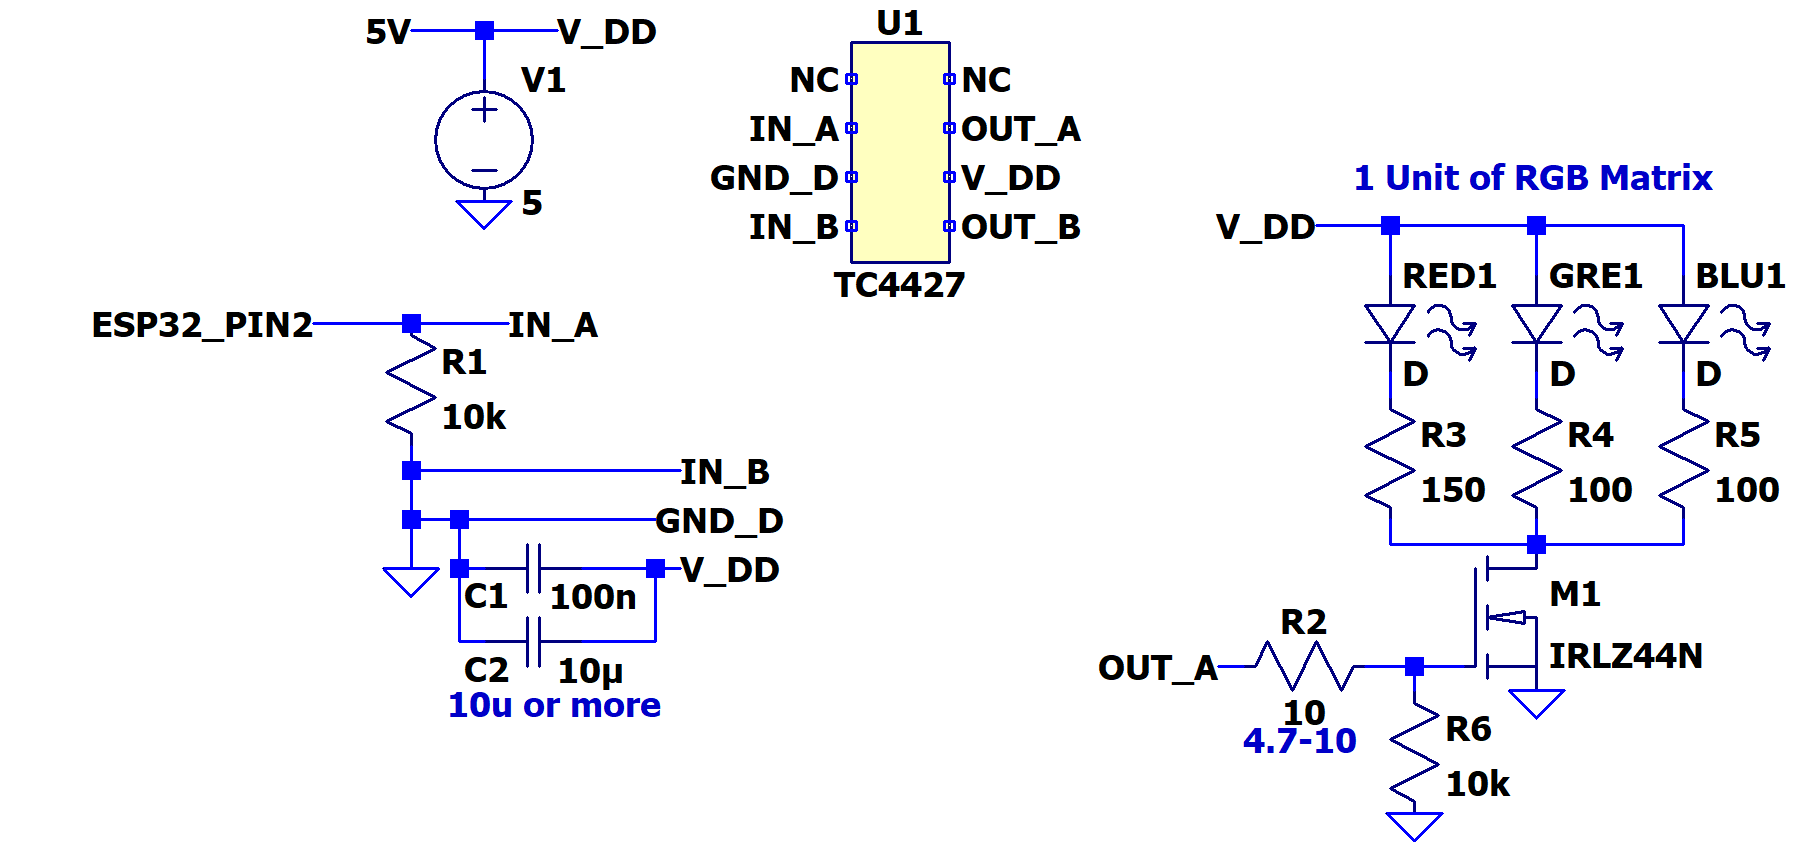

##### 3.1.2 Wejście sygnału i zabezpieczenia

Sygnał sterujący jest podawany z pinu mikrokontrolera na wejście **ESP32_PIN2**. Bezpośrednio do tej linii podłączony jest rezystor **R1** (10 kΩ) pełniący funkcję rezystora ściągającego do masy (ang. pull-down). Jest to proste, ale krytyczne zabezpieczenie sprzętowe. Gwarantuje ono, że w momencie uruchamiania mikrokontrolera (kiedy jego piny mogą znajdować się w stanie nieustalonym), na wejściu sterownika wymuszony zostanie stan niski (logiczne zero). Dzięki temu matryca LED pozostanie zgaszona i nie wygeneruje przypadkowych błysków zakłócających pracę układu.

##### 3.1.3 Sterownik tranzystora (Driver TC4427)

Sygnał logiczny trafia na wejście **IN_A** sterownika TC4427. Jak uzasadniono w rozdziale 2, układ ten działa jako wzmacniacz prądowy. Ponieważ scalony sterownik TC4427 posiada dwa niezależne kanały, a do sterowania matrycą potrzebny jest tylko jeden, wejście nieużywanego kanału **IN_B** zostało na stałe połączone z masą (GND_D). Zapobiega to zbieraniu zakłóceń elektromagnetycznych z otoczenia przez "wiszący" w powietrzu pin.

Bardzo ważnym elementem tego bloku są dwa kondensatory filtrujące, połączone równolegle: mały ceramiczny **C1** (100 nF) oraz większy elektrolityczny **C2** (10 µF). Umieszcza się je fizycznie jak najbliżej pinów zasilania układu scalonego (V_DD). Zastosowanie dwóch różnych typów kondensatorów obok siebie nie jest przypadkowe, ponieważ pełnią one zupełnie inne funkcje:

- Kondensator elektrolityczny (C2): Charakteryzuje się dużą pojemnością, dlatego działa jako lokalny, główny magazyn energii. Gdy sterownik potrzebuje nagle dużego prądu do otwarcia bramki tranzystora, pobiera go właśnie z tego kondensatora. Zapobiega to gwałtownym spadkom napięcia na głównej linii zasilającej, które mogłyby zresetować mikrokontroler. Z punktu widzenia fizyki, kondensatory elektrolityczne są jednak stosunkowo "wolne" i słabo radzą sobie z wysokimi częstotliwościami.

- Kondensator ceramiczny (C1): Posiada znacznie mniejszą pojemność, ale jego budowa sprawia, że reaguje błyskawicznie. To on tłumi najszybsze i najkrótsze zakłócenia (tzw. szpilki napięciowe) oraz filtruje szumy o wysokiej częstotliwości, które powstają przy ciągłym, milionowym przełączaniu tranzystora.

Współpraca tych dwóch kondensatorów gwarantuje, że sterownik TC4427 ma zawsze stabilne zasilanie, co bezpośrednio przekłada się na czysty i stabilny sygnał świetlny.

##### 3.1.4 Tranzystor kluczujący i obwód matrycy LED

Wzmocniony sygnał wychodzi z pinu **OUT_A** i wysterowuje bramkę n-kanałowego tranzystora MOSFET IRLZ44N (oznaczonego jako M1). Na linii tej znajduje się rezystor bramkowy **R2** o niewielkiej wartości (od 4.7 Ω do 10 Ω). Jego głównym zadaniem jest ograniczenie chwilowego prądu płynącego ze sterownika do bramki oraz tłumienie oscylacji sygnału (tzw. dzwonienia), które mogłyby zniekształcić przesyłane dane optyczne. Rezystor **R6** (10 kΩ) to kolejne zabezpieczenie ściągające bramkę tranzystora do masy, zapewniające jego pewne wyłączenie.

Tranzystor **M1** pracuje w bardzo popularnej konfiguracji tzw. klucza od strony masy (ang. Low-Side Switch). Oznacza to, że zasilanie 5V (V_DD) jest doprowadzone na stałe do diod LED.
Na schemacie zilustrowano pojedynczy moduł (piksel) matrycy RGB. Pracuje on w konfiguracji wspólnej anody (Common Anode). Do każdej z diod składowych (Czerwona – RED1, Zielona – GRE1, Niebieska – BLU1) dobrano odpowiedni rezystor ograniczający prąd (R3, R4, R5). Wartości te (150 Ω i 100 Ω) wyliczono specjalnie dla napięcia 5V, biorąc pod uwagę różnice w spadkach napięć na poszczególnych kolorach diod. Katody wszystkich diod połączone są za rezystorami w jeden węzeł, który podłączony jest do drenu (D) tranzystora.

W momencie, gdy tranzystor **M1** zostaje otwarty przez sterownik, obwód zamyka się do masy i wszystkie trzy diody składowe zapalają się jednocześnie. Wymieszanie barw R, G i B emituje jasne światło pełniące funkcję oświetleniową, podczas gdy szybkie załączanie i wyłączanie tranzystora realizuje niewidoczną dla ludzkiego oka komunikację VLC.

##### 3.1.5 Dobór empiryczny komponentów w fazie prototypowania

Należy w tym miejscu zaznaczyć ważny aspekt praktyczny. O ile wartości kondensatorów filtrujących (C1, C2) oraz rezystora bramkowego (R2) można wstępnie założyć teoretycznie, ich idealne wyliczenie matematyczne "na papierze" jest w praktyce niemożliwe. W układach przełączających się z dużą szybkością, na sygnał ogromny wpływ mają fizyczne cechy samego zbudowanego obwodu – na przykład długość użytych przewodów, rezystancja lutów czy tak zwane pojemności i indukcyjności pasożytnicze płytki montażowej.

Z tego względu, wartości zapisane na obecnym schemacie ideowym są wartościami referencyjnymi. Dokładny dobór tych elementów zostaje celowo przeniesiony na etap fizycznej budowy i testowania systemu. Ostateczna optymalizacja (np. wybór, czy rezystor bramkowy ma mieć wartość 4.7 Ω czy 10 Ω, aby najlepiej tłumić zakłócenia) zostanie przeprowadzona eksperymentalnie na podstawie rzeczywistych pomiarów sygnału przy użyciu oscyloskopu.



#### 3.2. Projekt toru odbiorczego i filtracja zakłóceń

Odbiór sygnału optycznego (VLC) jest procesem znacznie trudniejszym niż jego nadawanie. Fotodioda odbiera nie tylko nasz użyteczny sygnał z lampy (dane), ale również potężne zakłócenia z otoczenia: światło słoneczne oraz migotanie standardowych żarówek zasilanych z sieci energetycznej. Z tego powodu zaprojektowano zaawansowany wielostopniowy obwód analogowy (Analog Frontend). Symulację oraz weryfikację przeprowadzono w programie LTSpice.

##### 3.2.1 Schemat Odbiornika w LTSpice
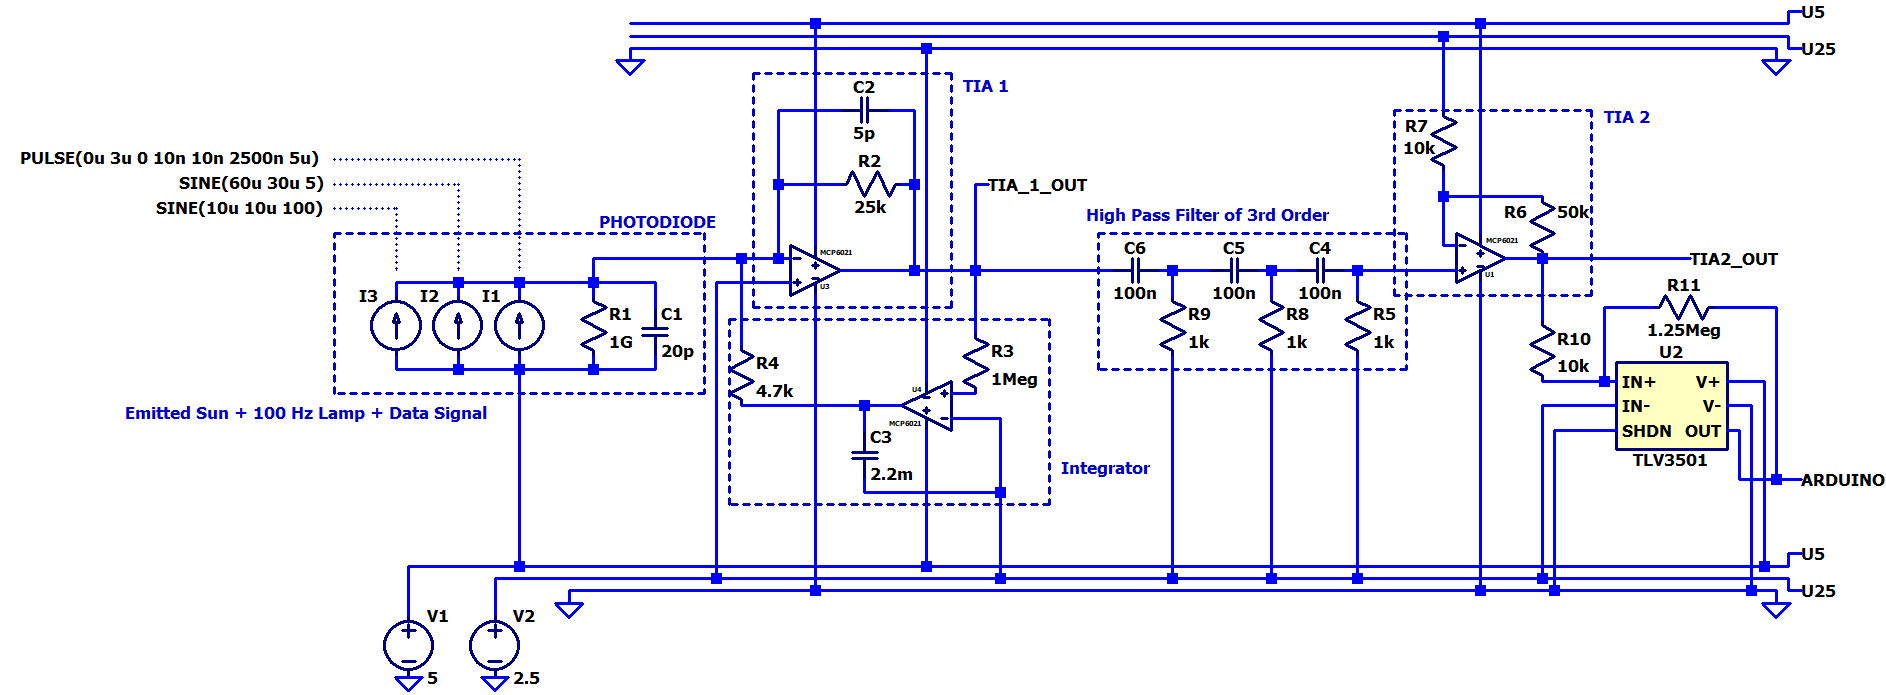

W celu dokładnego przetestowania układu, na schemacie stworzono model fotodiody składający się z trzech źródeł prądowych:
- I3 (PULSE): Symuluje nasz szybki, użyteczny sygnał z danymi (VLC).
- I2 (SINE 60u): Symuluje wolno zmieniające się, bardzo silne światło słoneczne (komponenta stała - DC).
- I1 (SINE 10u): Symuluje migotanie zwykłych lamp w pomieszczeniu (częstotliwość 100 Hz wynikająca z prostowania napięcia sieciowego 50 Hz).

##### 3.2.2 Pierwszy stopień: Wzmacniacz TIA 1 oraz Integrator (Walka ze słońcem)

Sygnał prądowy z fotodiody jest niezwykle słaby, dlatego musi natychmiast trafić do wzmacniacza transimpedancyjnego **TIA 1**. Głównym elementem tego bloku jest wzmacniacz operacyjny **U3** (MCP6021). Jego zadaniem jest zamiana prądu z fotodiody na czytelne napięcie. Rezystor sprzężenia zwrotnego **R2** (25 kΩ) ustala wielkość tego wzmocnienia, a mały kondensator **C2** (5 pF) stabilizuje układ, zapobiegając jego wzbudzaniu się (tzw. dzwonieniu). Cały tor analogowy zasilany jest napięciem 5V, jednak dla poprawnej pracy sygnałów zmiennych wprowadzono napięcie odniesienia (sztuczną masę) na poziomie 2.5V.

Główne wzmocnienie transimpedancyjne pierwszego stopnia zależy wprost od rezystora sprzężenia zwrotnego $R_2$. Dla prądów sygnału użytecznego (VLC) wynosi ono:

$$Z_T = R_2 = 25 \text{ k}\Omega = 25000 \text{ V/A}$$

Największym zagrożeniem dla wzmacniacza TIA 1 jest światło słoneczne **I2**. Ponieważ słońce świeci bardzo mocno, stały prąd z fotodiody mógłby natychmiast "oślepić" wzmacniacz (doprowadzić do nasycenia), przez co przestałby on widzieć szybkie impulsy danych. Aby temu zapobiec, dodano układ **Integratora** (oparty na wzmacniaczu U4). Działa on jako aktywna pętla sprzężenia zwrotnego (tzw. DC Servo). Integrator "obserwuje" wyjście TIA 1, wyłapuje wolno zmieniające się napięcie ze światła słonecznego i automatycznie je odejmuje bezpośrednio na wejściu wzmacniacza. Dzięki temu pierwszy stopień ignoruje światło otoczenia i wzmacnia tylko szybkie zmiany sygnału.

Kluczowym parametrem jest jednak graniczna wydajność Integratora, czyli maksymalny prąd stały (od słońca), jaki układ potrafi skompensować bez wchodzenia w nasycenie. Maksymalne napięcie, jakie wzmacniacz U4 może wygenerować, wynosi około $V_{CC} = 5\text{V}$. Napięcie odniesienia fotodiody wynosi $V_{ref} = 2.5\text{V}$. Maksymalny prąd kompensacyjny ($I_{max}$), płynący przez rezystor $R_4$, wynosi zatem:$$I_{max} = \frac{V_{CC} - V_{ref}}{R_4} = \frac{5\text{V} - 2.5\text{V}}{4700 \text{ } \Omega} \approx 531.9 \text{ } \mu\text{A}$$Ponieważ symulowane, bardzo silne światło słoneczne (I2) generuje prąd o wartości $60 \text{ } \mu\text{A}$, układ posiada ponad 8-krotny margines bezpieczeństwa i nie ulegnie "oślepieniu".

##### 3.2.3 Drugi stopień: Pasywny filtr górnoprzepustowy (Walka z żarówkami 100 Hz)

Choć Integrator radzi sobie ze słońcem, w sygnale wciąż pozostają zakłócenia od sztucznego oświetlenia (100 Hz). Aby oczyścić z nich nasz sygnał danych, zastosowano pasywny filtr górnoprzepustowy (HPF) trzeciego rzędu. Składa się on z trzech kaskadowo połączonych członów RC (kondensatory C4, C5, C6 o pojemności 100 nF oraz rezystory R5, R8, R9 o wartości 1 kΩ). Filtr ten bez problemu przepuszcza bardzo szybkie impulsy (nasze dane rzędu setek kHz i MHz), ale fizycznie blokuje wolniejsze oscylacje (np. 100 Hz z sieci), odcinając resztę szumu.

Zastosowany pasywny filtr górnoprzepustowy (HPF) składa się z trzech identycznych członów RC. Częstotliwość odcięcia ($f_c$) dla pojedynczego członu (np. R9 i C6) oblicza się ze standardowego wzoru: $$f_c = \frac{1}{2\pi \cdot R \cdot C} = \frac{1}{2\pi \cdot 1000 \text{ } \Omega \cdot 100 \cdot 10^{-9} \text{ F}} \approx 1591 \text{ Hz}$$ Dzięki kaskadowemu połączeniu trzech takich samych członów, filtr staje się bardziej stromy. Zapewnia to potężne, niemal całkowite tłumienie zakłóceń o częstotliwości 100 Hz (od żarówek i świetlówek sieciowych), swobodnie przepuszczając jednocześnie szybkie sygnały VLC (powyżej kilkuset kHz).

##### 3.2.4 Trzeci stopień: Wzmacniacz napięciowy (TIA 2)

Po przejściu przez potrójny filtr pasywny, sygnał danych jest w pełni wolny od zakłóceń świetlnych, ale staje się osłabiony. Dlatego na samym końcu schematu umieszczono kolejny wzmacniacz operacyjny **U1**. Pracuje on w konfiguracji klasycznego wzmacniacza nieodwracającego. Jego wzmocnienie napięciowe ($A_v$) definiują rezystory $R_6$ i $R_7$: $$A_v = 1 + \frac{R_6}{R_7} = 1 + \frac{50 \text{ k}\Omega}{10 \text{ k}\Omega} = 6 \text{ V/V}$$ Oznacza to, że odfiltrowany, czysty sygnał jest na tym etapie powiększany 6-krotnie, aby przygotować go do cyfryzacji.

##### 3.2.5 Czwarty stopień: Komparator z histerezą (Cyfryzacja sygnału)

Ostatnim, krytycznym elementem toru odbiorczego jest szybki komparator **U2** (zastosowano model TLV3501, cechujący się bardzo krótkim czasem propagacji). Nawet po odfiltrowaniu i wzmocnieniu, sygnał wychodzący z TIA 2 jest nadal sygnałem analogowym – posiada łagodne zbocza i pewien poziom szumu termicznego. Mikrokontroler węzła końcowego (np. Arduino) nie potrafi bezpośrednio i niezawodnie odczytać takiego sygnału przez przerwanie cyfrowe.Zadaniem komparatora jest zamiana analogowej fali na idealnie ostre impulsy logiczne (0V lub 5V). 

Sygnał analogowy wprowadzany jest na wejście odwracające (IN-) poprzez rezystor $R_{10}$ (10 kΩ). Do wejścia dodatniego (IN+) doprowadzono napięcie odniesienia $2.5\text{V}$. Dodatkowo, aby układ był odporny na zjawisko "drgania" (multiple triggering) podczas powolnego przechodzenia sygnału przez próg odniesienia, zastosowano rezystor sprzężenia zwrotnego $R_{11}$ (1.25 MΩ). Rezystory $R_{10}$ i $R_{11}$ tworzą tak zwany przerzutnik Schmitta, który wprowadza okno histerezy. Szerokość pętli histerezy ($\Delta V_{hyst}$) określa różnicę napięć między progiem włączenia a wyłączenia i oblicza się ją ze wzoru:$$\Delta V_{hyst} \approx V_{CC} \cdot \frac{R_{10}}{R_{10} + R_{11}}$$ $$\Delta V_{hyst} \approx 5\text{V} \cdot \frac{10 \text{ k}\Omega}{10 \text{ k}\Omega + 1250 \text{ k}\Omega} = 5\text{V} \cdot \frac{10}{1260} \approx 39.6 \text{ mV}$$ Wartość histerezy na poziomie ok. $40 \text{ mV}$ jest rozwiązaniem optymalnym. Gwarantuje ona, że drobny szum elektryczny nie wyzwoli fałszywego przerwania, ale jednocześnie układ pozostaje niezwykle czuły na właściwe impulsy danych świetlnych. Wynikiem pracy tego stopnia jest gotowy, czysty sygnał cyfrowy wyprowadzony na pin OUT, który trafia bezpośrednio do mikrokontrolera (Arduino) w celu zdekodowania transmisji.
